In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import mne
import re
os.chdir(r'D:\Thesis\ThesisEEG\ds003969-download')

In [2]:
import mne
sub = "085"         
task = "med1breath"  
base_path = r"D:\Thesis\ThesisEEG\ds003969-download"
bdf_path = fr"{base_path}\sub-{sub}\eeg\sub-{sub}_task-{task}_eeg.bdf"
raw = mne.io.read_raw_bdf(bdf_path, preload=True)


Extracting BDF parameters from D:\Thesis\ThesisEEG\ds003969-download\sub-085\eeg\sub-085_task-med1breath_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 618495  =      0.000 ...   603.999 secs...


Using matplotlib as 2D backend.


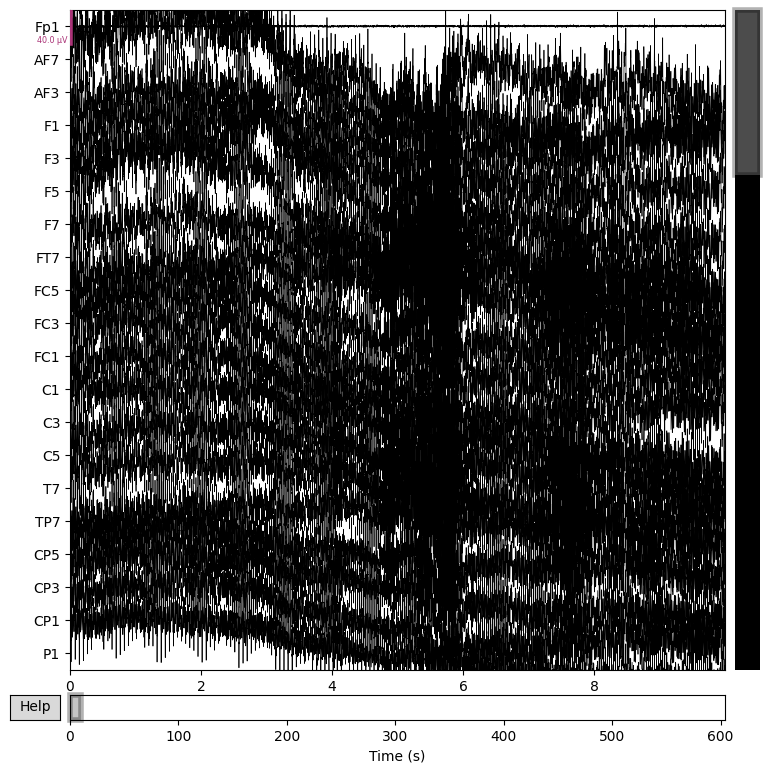

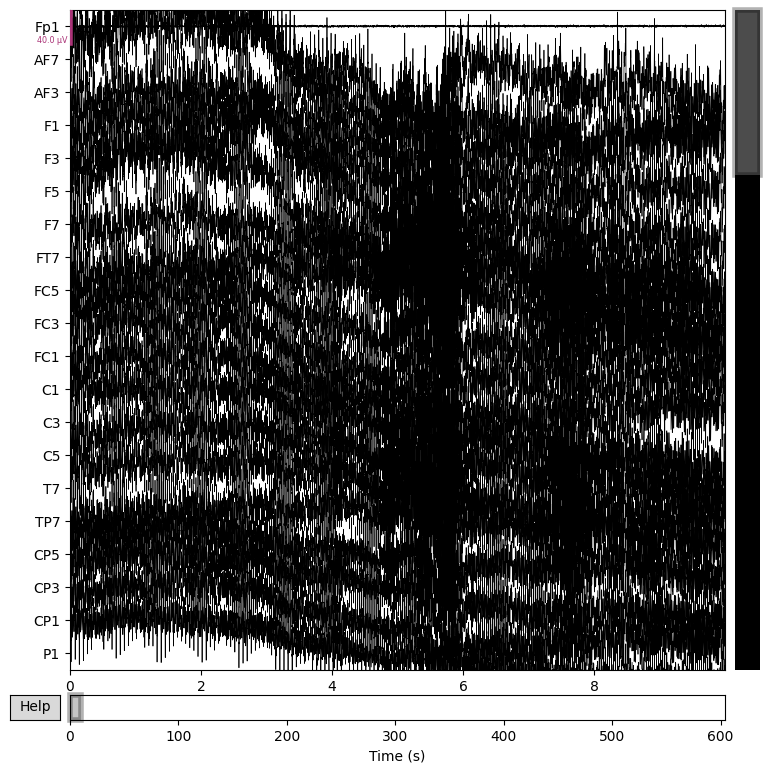

In [3]:
raw.plot()

In [2]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2009-04-07 11:08:40 UTC
 nchan: 73
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: >
>

In [ ]:
mne.preprocessing.find_bad_channels_lof(raw, n_neighbors=20, picks=None, metric='euclidean', threshold=1.5, return_scores=False, verbose=None)

LOF: Detected bad channel(s): ['Fp1', 'PO3', 'POz', 'CPz', 'FT8', 'EXG3', 'EXG5', 'GSR1', 'GSR2', 'Resp', 'Plet', 'Temp']


['Fp1',
 'PO3',
 'POz',
 'CPz',
 'FT8',
 'EXG3',
 'EXG5',
 'GSR1',
 'GSR2',
 'Resp',
 'Plet',
 'Temp']

In [9]:
bad_channels = mne.preprocessing.find_bad_channels_lof(raw, n_neighbors=20, picks=None, metric='euclidean', threshold=1.5, return_scores=False, verbose=None)
df = pd.DataFrame({'bad_channels': bad_channels})
df.to_excel('bad_channels.xlsx', index=False)
print("Bad channels saved to bad_channels.xlsx")

LOF: Detected bad channel(s): ['Fp1', 'PO3', 'POz', 'CPz', 'FT8', 'EXG3', 'EXG5', 'GSR1', 'GSR2', 'Resp', 'Plet', 'Temp']
Bad channels saved to bad_channels.xlsx


Setting up band-pass filter from 1 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 40.00 Hz: -6.02, -6.02 dB

Using matplotlib as 2D backend.


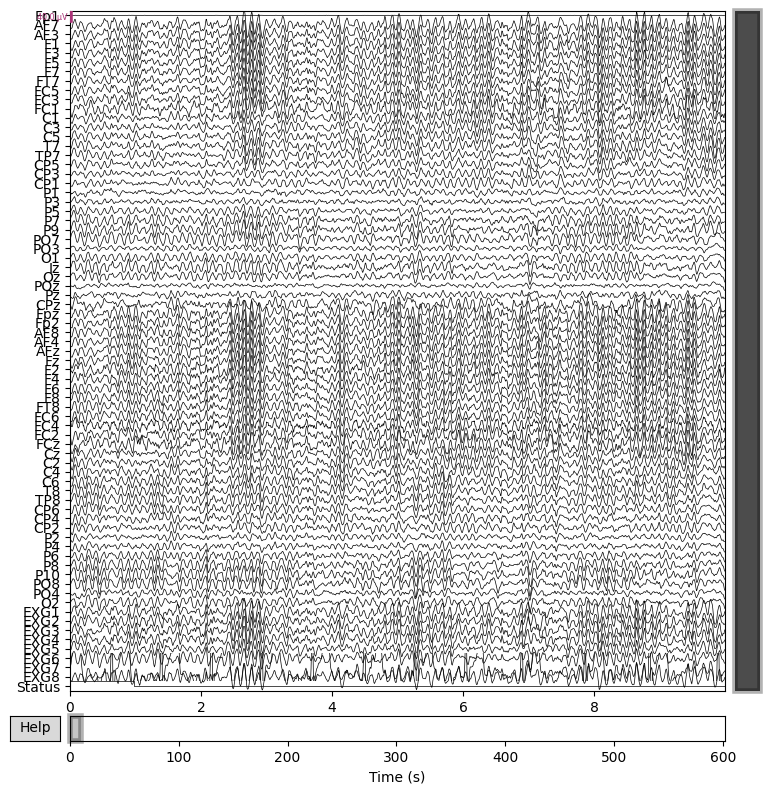

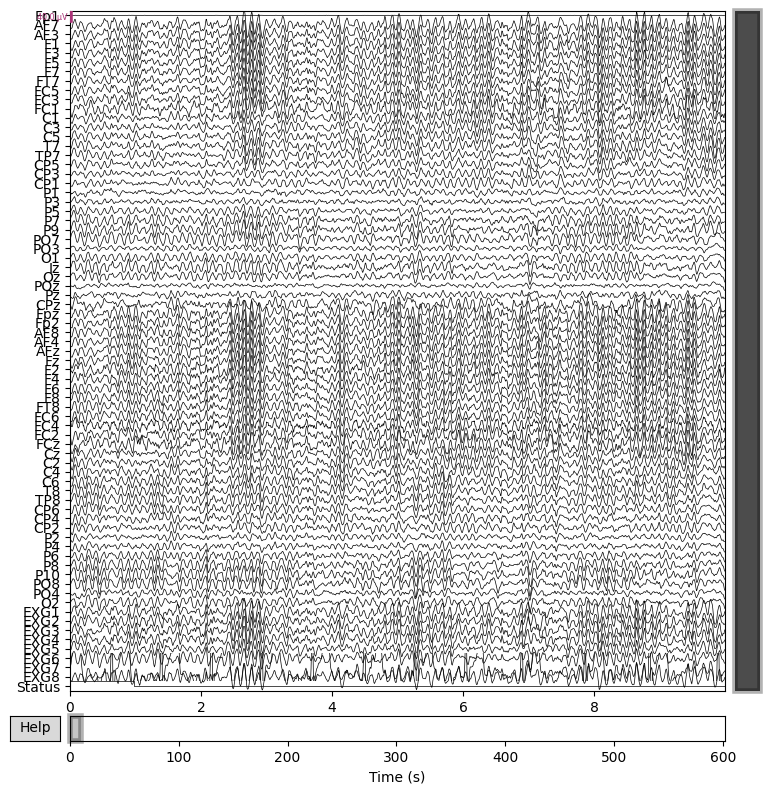

In [3]:
raw.plot( n_channels=80, lowpass=40, highpass=1)

In [ ]:
print(raw.info["bads"])

[]
